## Introduction

This notebook serves to provide valuable data insights into the evaluations I choose for the NLP model. In here, I'll be using matplotlib.pyplot, seaborn, and possibly some audio visualizations to represent patterns in similar music genres as well as songs in general.

This notebook is mostly meant for visualization but can be custom-made in-order to visualize your own data you choose to modify the model with

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
    print("Cuda device is available")
elif not torch.backends.mps.is_available():
    device= "cpu"
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    device = "mps"
    print("Mac device available")

print(device)

Mac device available
mps


Index(['num', 'track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')


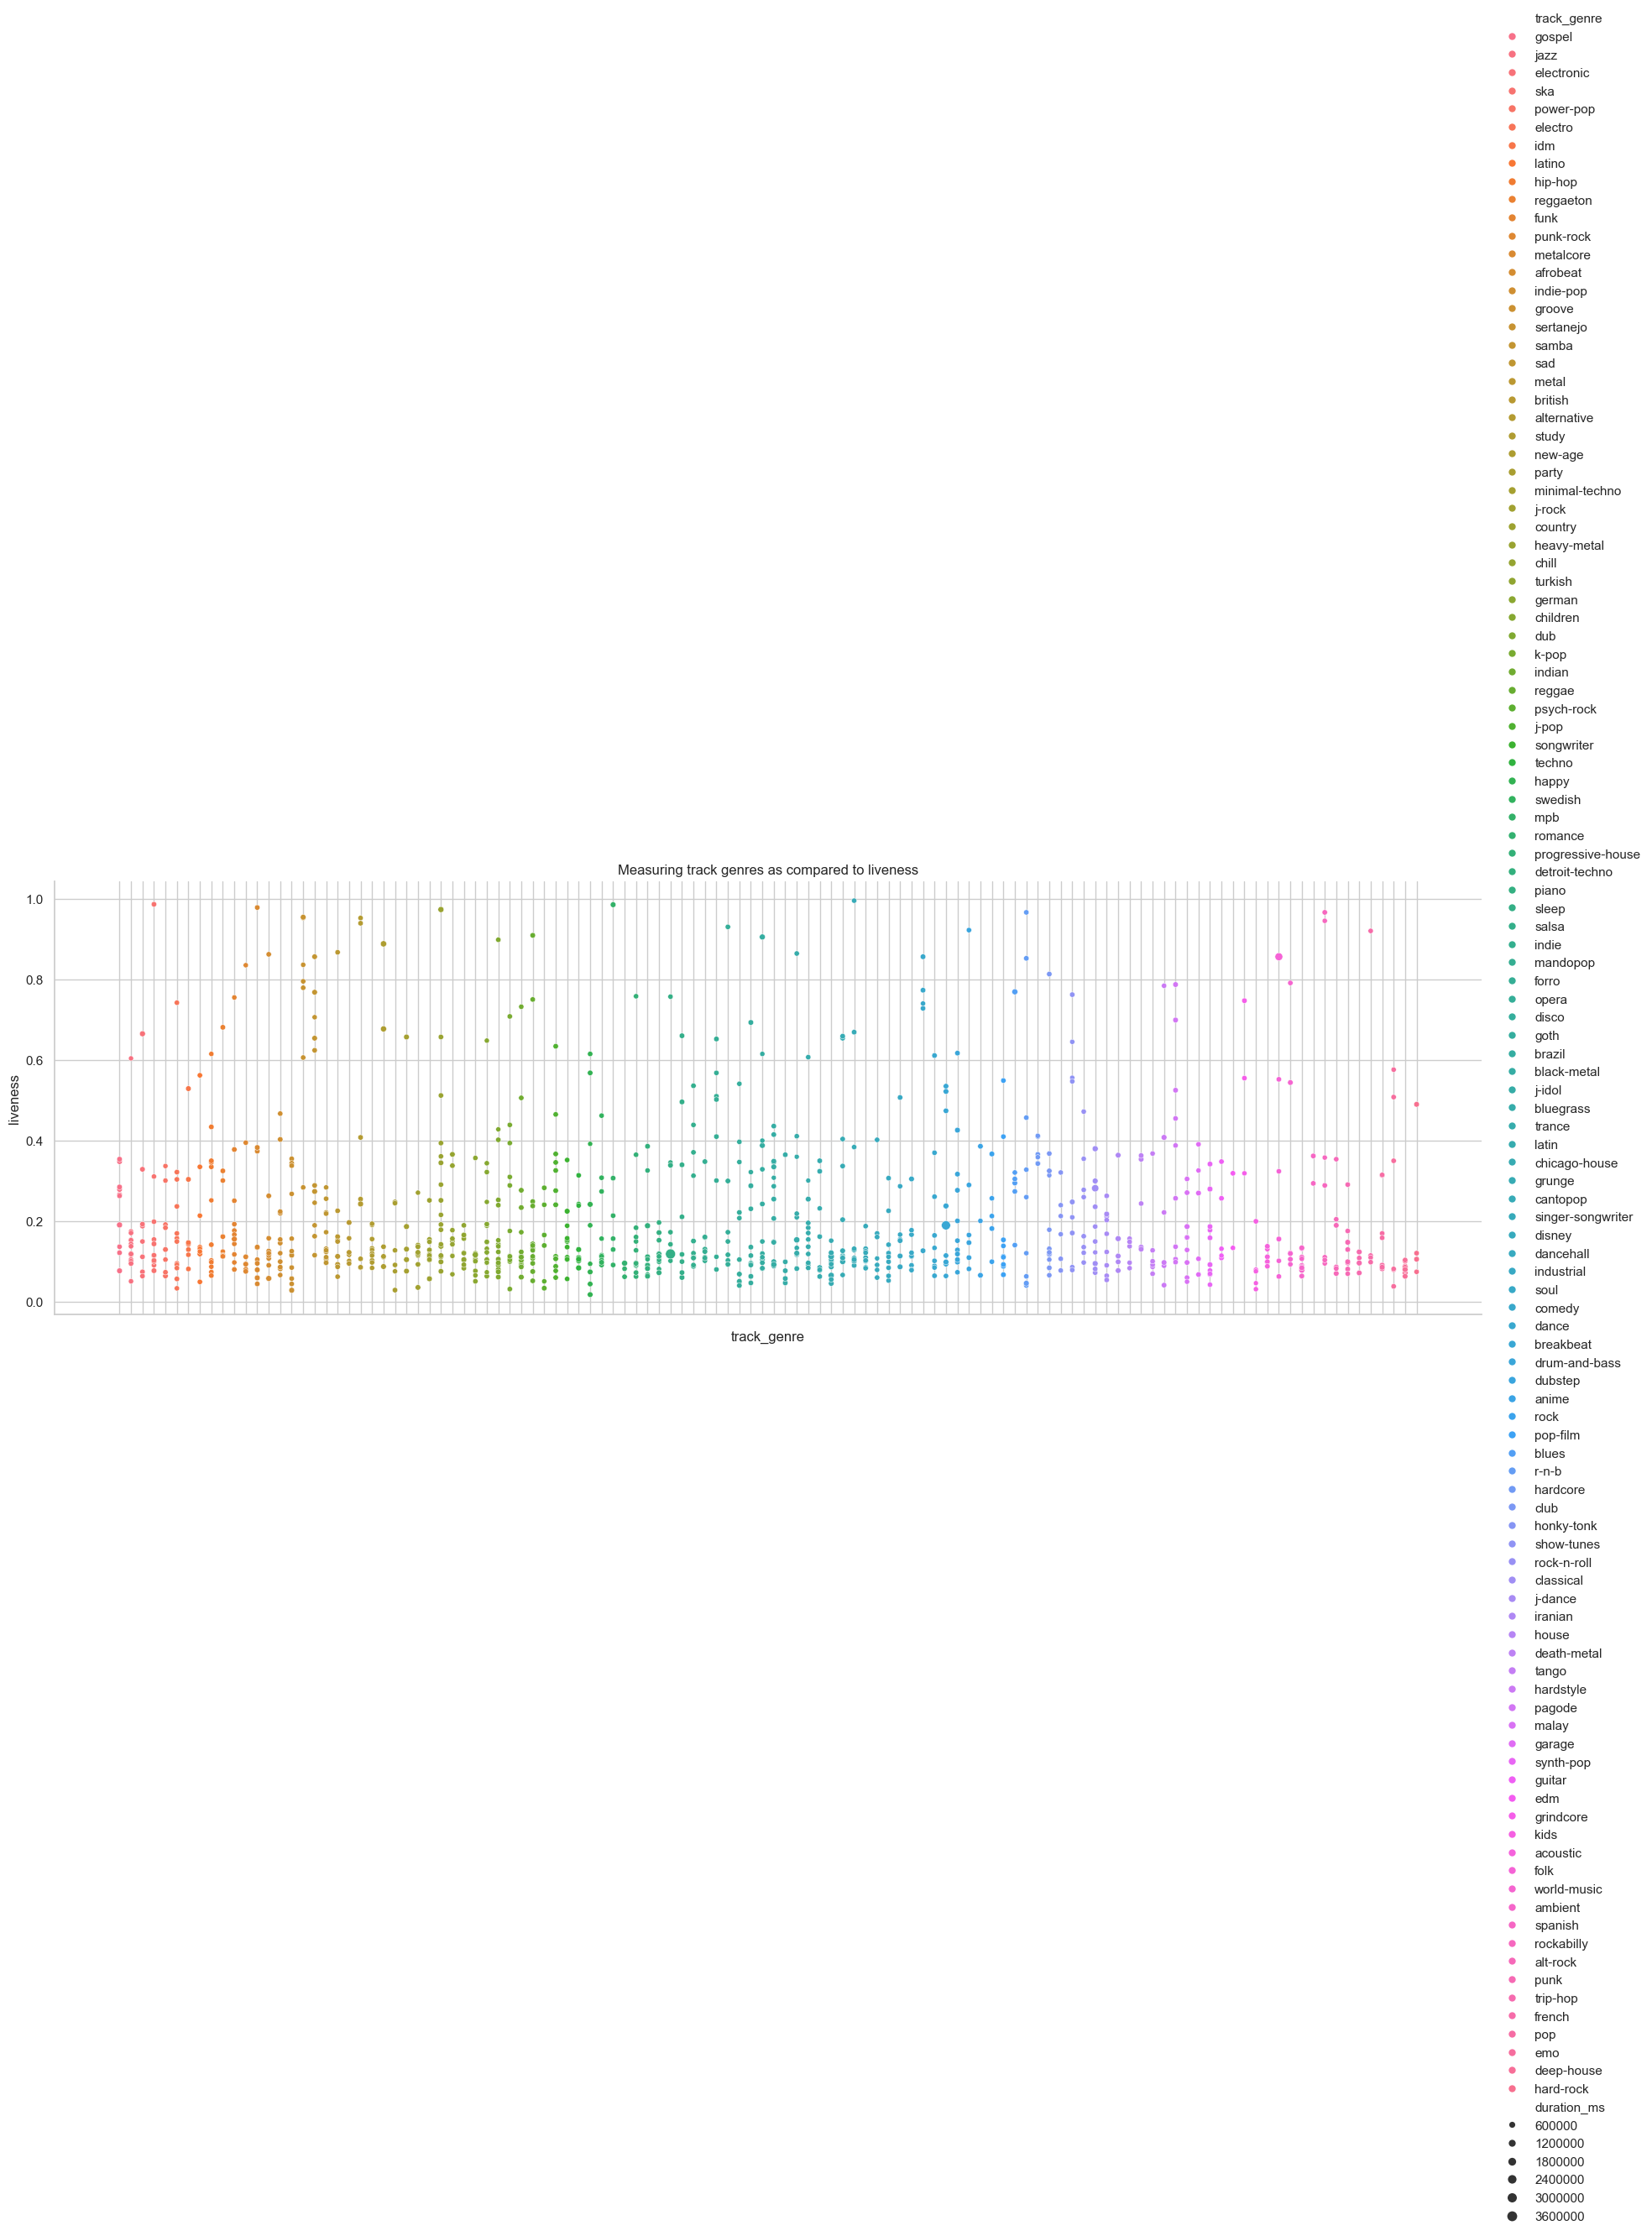

In [127]:
# We start by importing our libraries and plotting our model
import matplotlib.pyplot as plt
import seaborn as sns
from TrainingData.data.load_data import df
import random

# We are going to plot several interactions between our data to see what patterns we can draw
random.seed(40)
optimized_random_df = df.sample(n=1000, random_state=40)
beg = sns.relplot(data=optimized_random_df, x="track_genre", y="liveness",hue='track_genre', size="duration_ms",kind="scatter", legend="auto", height =6, aspect=3)
beg.set(xticklabels=[])
beg.set(title="Measuring track genres as compared to liveness")
plt.show()


In [128]:
print(len(df["track_genre"].unique()))

114


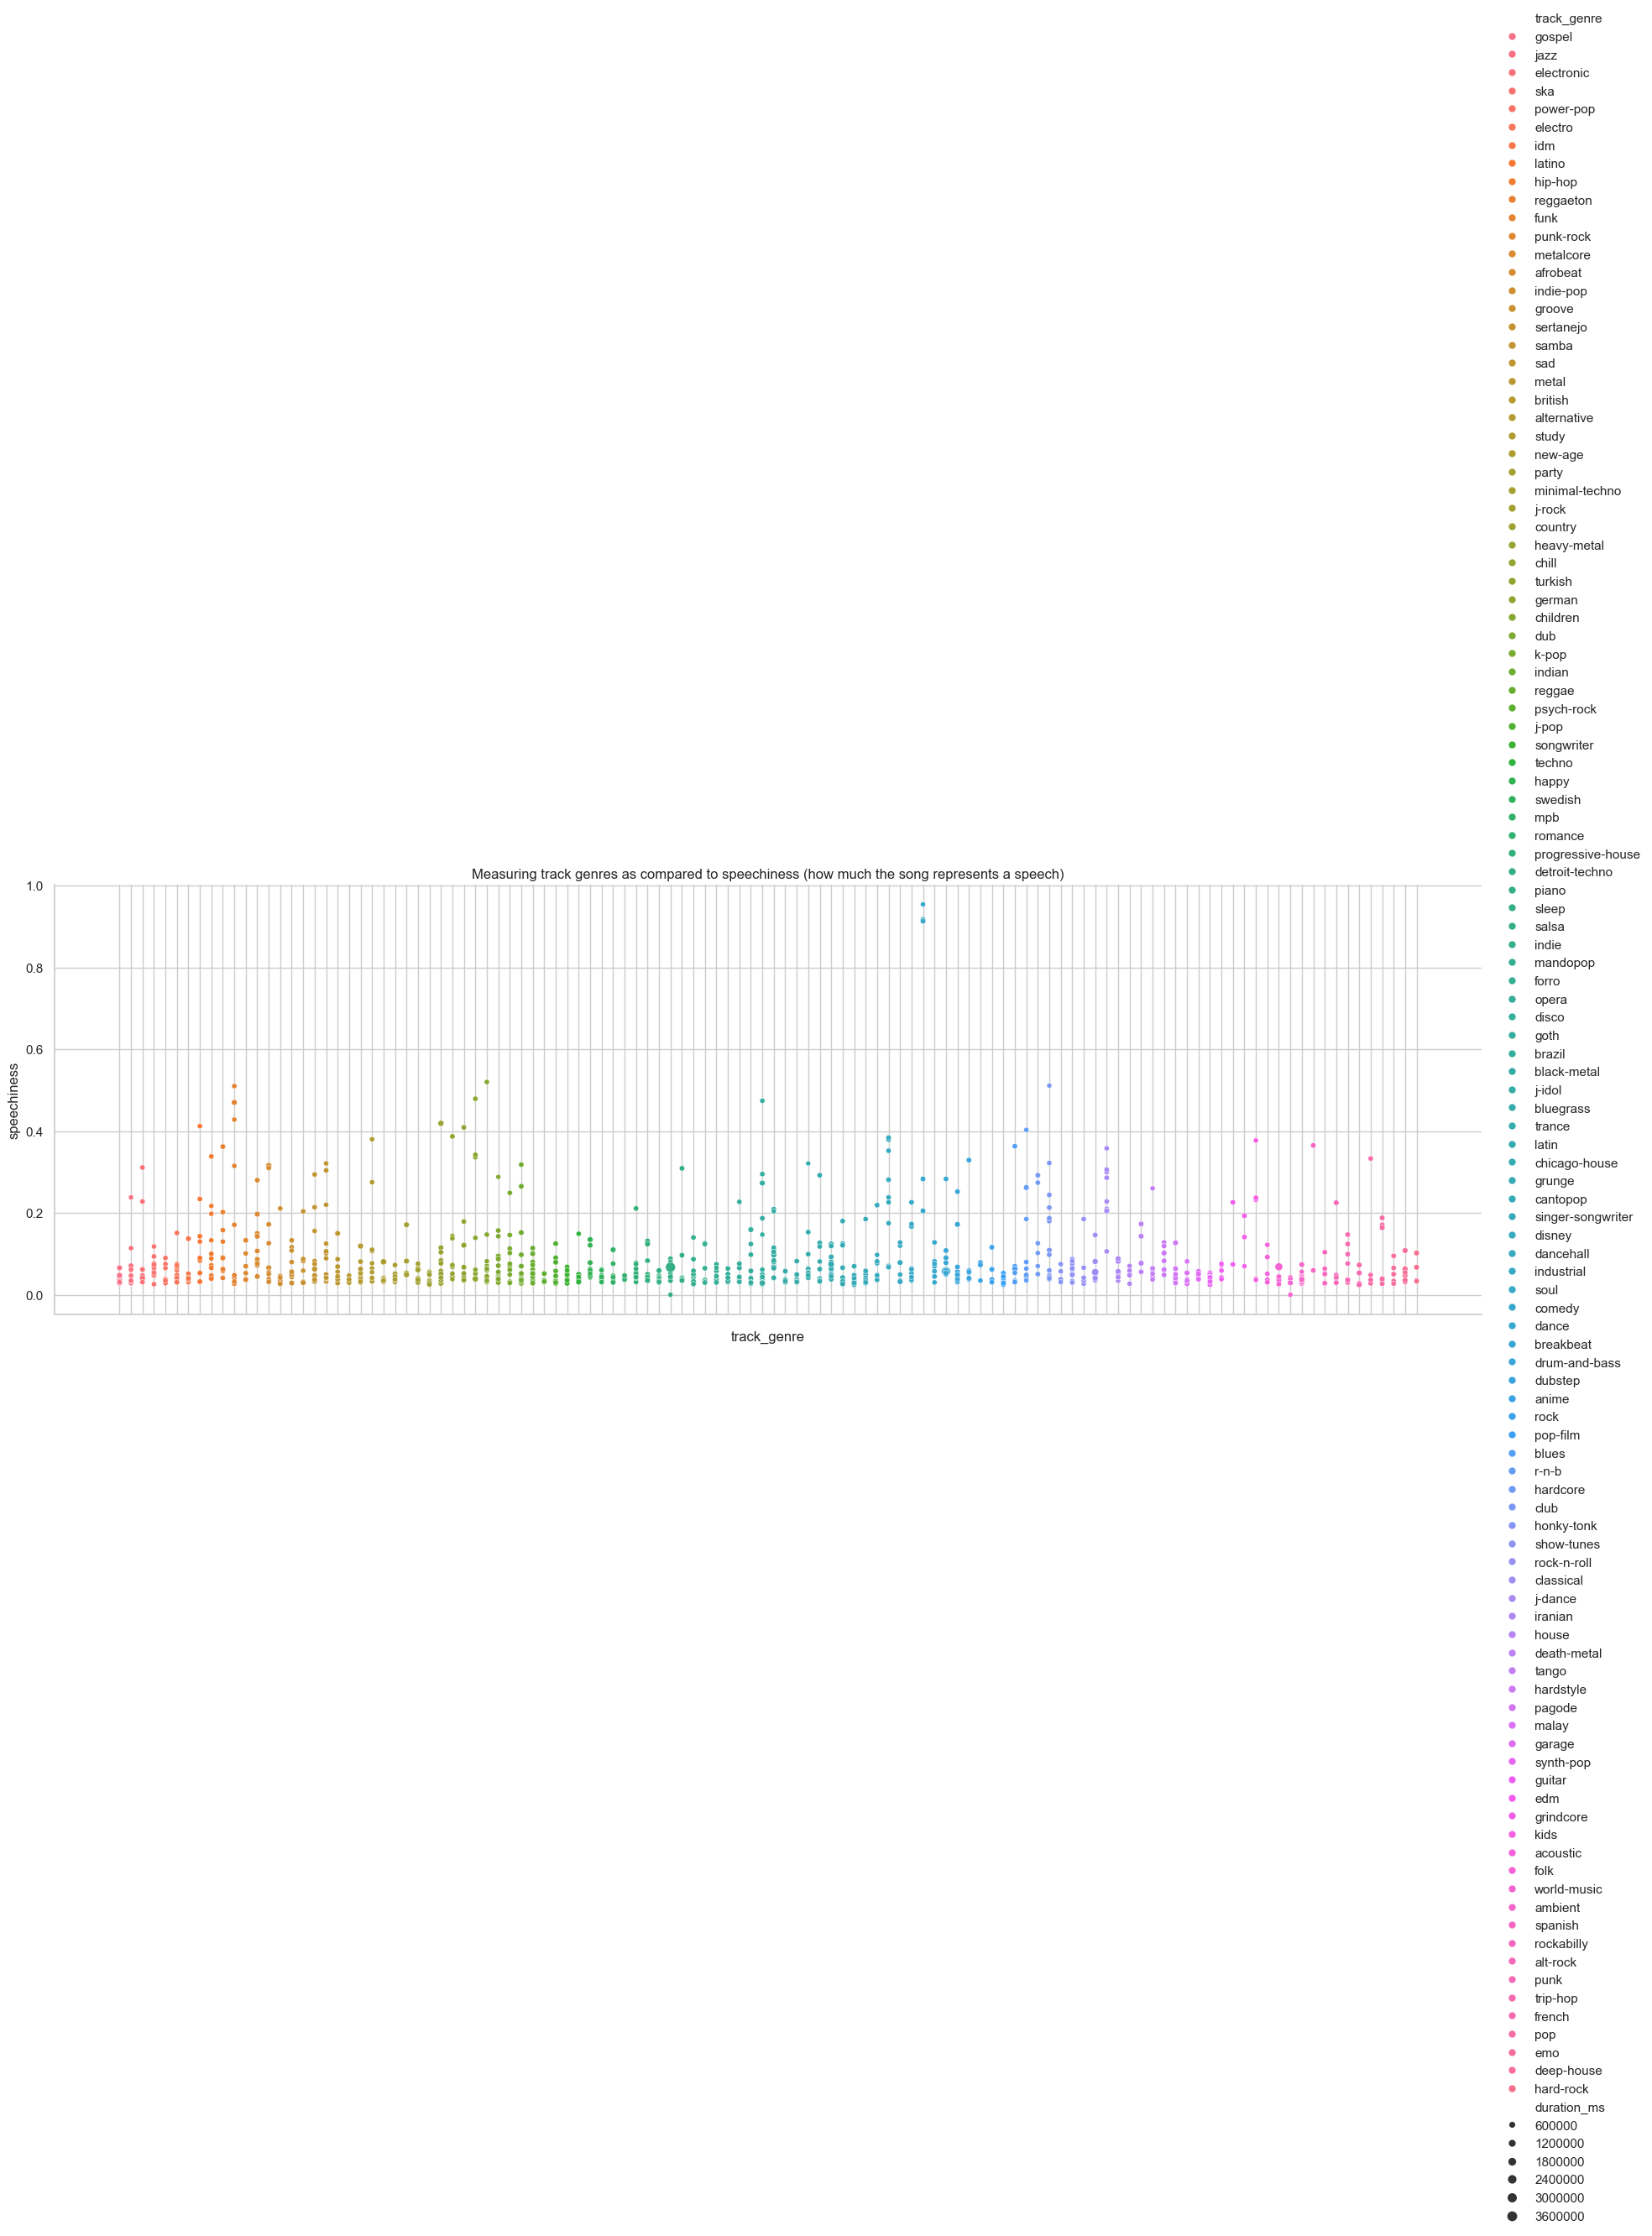

In [129]:
val = sns.relplot(data=optimized_random_df, x="track_genre", y="speechiness",hue='track_genre', size="duration_ms",kind="scatter", legend="auto", height =6, aspect=3)
val.set(xticklabels=[])
val.set(title="Measuring track genres as compared to speechiness (how much the song represents a speech)")
plt.show()


We can see from the data above that there may be a strong correlation between the genre of a spotify song as well as its liveliness and speechiness. This may prove helpful to predicting songs.

## Investigating further relationships

Now that we have an idea about what variables may help us find similar songs for our engine, we now want to see the relationships between them. Is there a correlation between speechiness and liveness, and can we reveal anything about how genres can vary using this.

### Violinplot of energy against speechiness

The following plot will show us how speechiness correlates with energy based on the kernel density at specific points of the graph. Essentially, what's the distribution of energy and speechiness overall correlated with.

<Axes: xlabel='energy', ylabel='speechiness'>

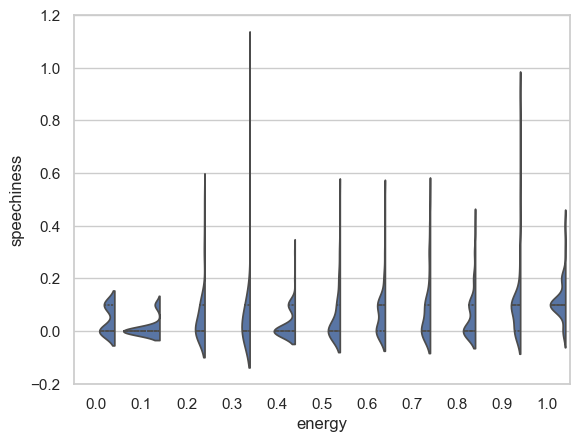

In [216]:
optimized_random_df_rounded = optimized_random_df.round({'speechiness': 1, 'liveness': 1, "energy": 1, "popularity": 1, "danceability": 1})
mean_values = optimized_random_df_rounded.groupby('energy')['speechiness'].mean()
sns.set_theme(style="whitegrid")
sns.violinplot(x='energy', y='speechiness', split=True, inner="quart", data=optimized_random_df_rounded)



We can see from the results above that while speechiness might be on an upwards trend as we increase energy, the reality is that most of the density is held straight in the middle. This means that for a majority of the data, energy and speechiness have essentially no correlation and won't tell us much in preperation for our model.

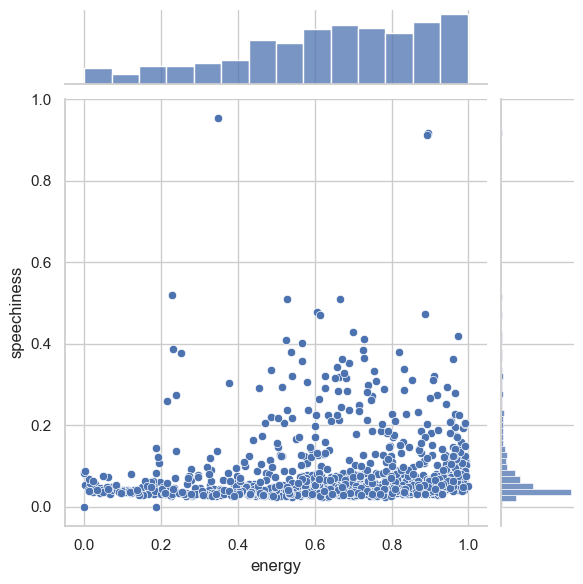

In [223]:
df_head = df.head(5)
df_tail = df.tail(5)
sns.set_theme(style="whitegrid")
g = sns.JointGrid(optimized_random_df, x="energy", y="speechiness")
g.plot(sns.scatterplot, sns.histplot)

We can further see above that most songs tend to rest in the `0` to `.2` range, and therefore  our data won't be able to give us truly valuable insights in response to the correlation between these two features. While purely looking at energy in response to speechiness might show some patterns, the overwhelming amount of songs skewing the tail to the left of the distribution means our neural nets won't be able to draw true causation.

### Violinplots with track genre and speechiness


In [183]:
df_rounded = df.round({'speechiness': 1, 'liveness': 1, "energy": 1, "popularity": 1, "danceability": 1})

Next, we're going to analyze the correlations between energy, liveness, and energy directly

<Axes: xlabel='liveness', ylabel='energy'>

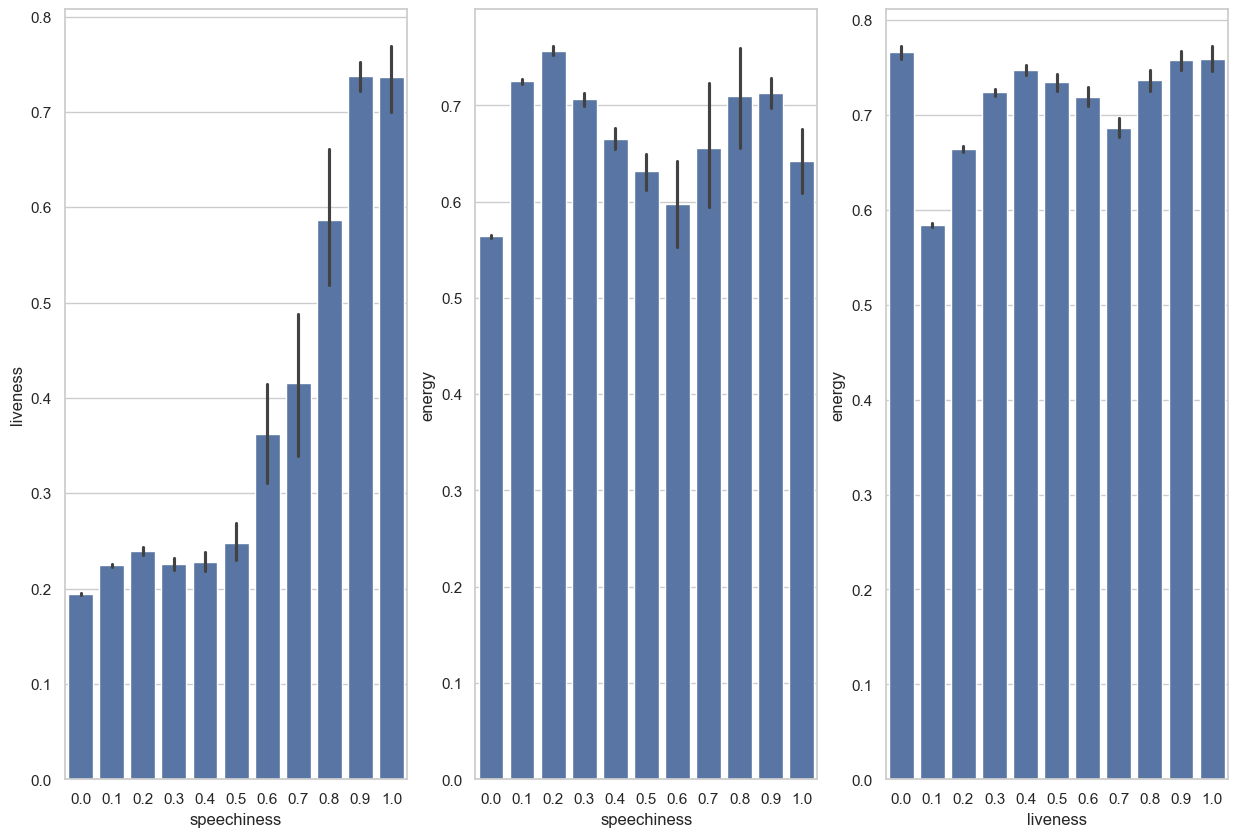

In [184]:
figure, axes = plt.subplots(1, 3, figsize=(15, 10))
sns.barplot(data=df_rounded, x="speechiness", y="liveness", ax=axes[0])
sns.barplot(data=df_rounded, x="speechiness", y="energy", ax=axes[1])
sns.barplot(data=df_rounded, x="liveness", y="energy", ax=axes[2])



We can see clearly that there is a strong correlation between speechiness and liveness, but since energy is pretty high across all of our songs, we can't get a very accurate correlation. Additionally, there is no downward or upward correlation, therefore energy may not be worth including in our model. Next, we're going to investigate danceability and popularity

<Axes: xlabel='speechiness', ylabel='danceability'>

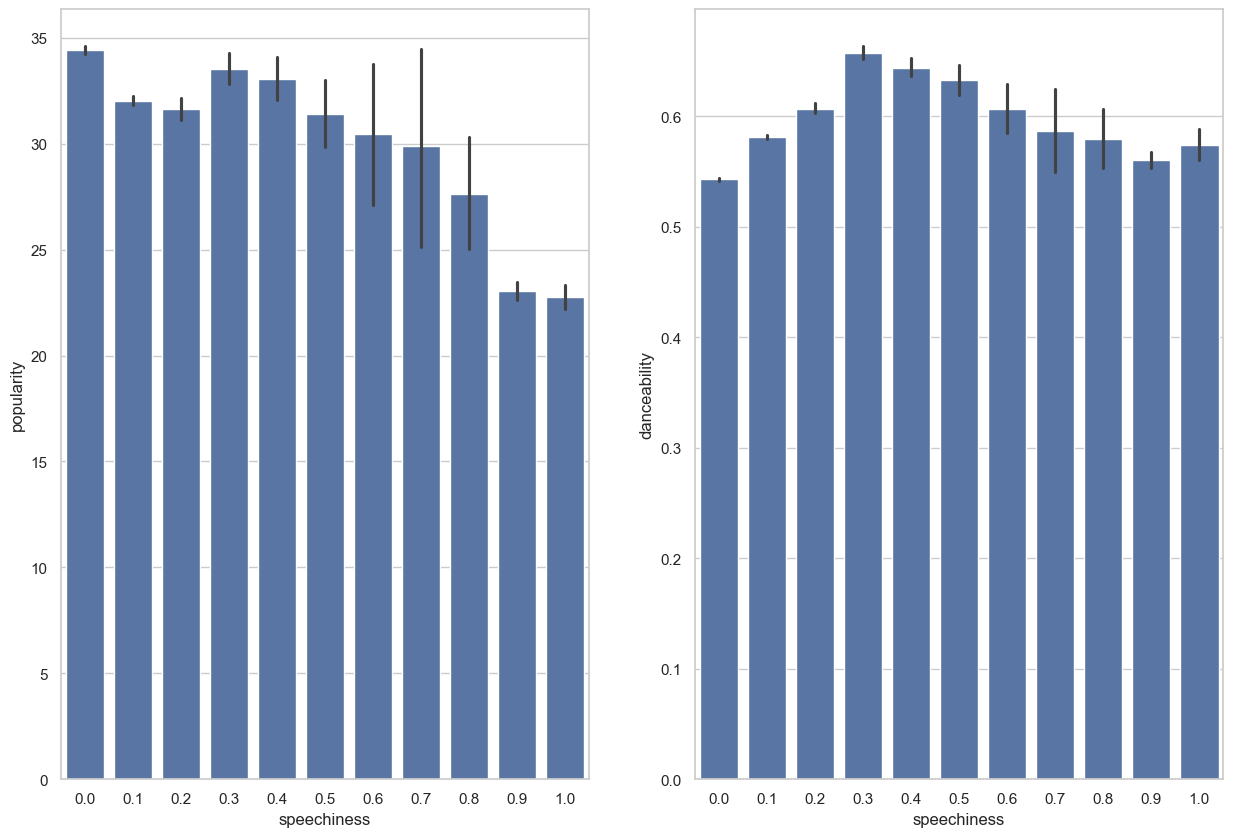

In [217]:
figure, axes = plt.subplots(1, 2, figsize=(15, 10))
sns.barplot(data=df_rounded, x="speechiness", y="popularity", ax=axes[0])
sns.barplot(data=df_rounded, x="speechiness", y="danceability", ax=axes[1])

<Axes: xlabel='speechiness', ylabel='liveness'>

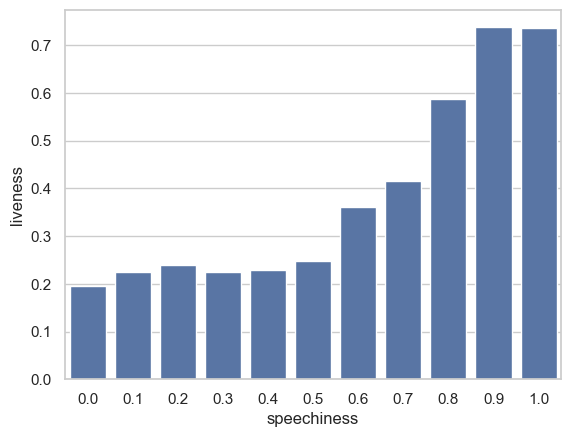

In [186]:
results = df_rounded.groupby("speechiness")["liveness"].mean().sort_values(ascending=False)
sns.barplot(results)

[[Text(0, 0, ''),
  Text(1, 0, ''),
  Text(2, 0, ''),
  Text(3, 0, ''),
  Text(4, 0, ''),
  Text(5, 0, ''),
  Text(6, 0, ''),
  Text(7, 0, ''),
  Text(8, 0, ''),
  Text(9, 0, ''),
  Text(10, 0, ''),
  Text(11, 0, ''),
  Text(12, 0, ''),
  Text(13, 0, ''),
  Text(14, 0, ''),
  Text(15, 0, ''),
  Text(16, 0, ''),
  Text(17, 0, ''),
  Text(18, 0, ''),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, ''),
  Text(24, 0, ''),
  Text(25, 0, ''),
  Text(26, 0, ''),
  Text(27, 0, ''),
  Text(28, 0, ''),
  Text(29, 0, ''),
  Text(30, 0, ''),
  Text(31, 0, ''),
  Text(32, 0, ''),
  Text(33, 0, ''),
  Text(34, 0, ''),
  Text(35, 0, ''),
  Text(36, 0, ''),
  Text(37, 0, ''),
  Text(38, 0, ''),
  Text(39, 0, ''),
  Text(40, 0, ''),
  Text(41, 0, ''),
  Text(42, 0, ''),
  Text(43, 0, ''),
  Text(44, 0, ''),
  Text(45, 0, ''),
  Text(46, 0, ''),
  Text(47, 0, ''),
  Text(48, 0, ''),
  Text(49, 0, ''),
  Text(50, 0, ''),
  Text(51, 0, ''),
  Text(52, 0, ''),
  T

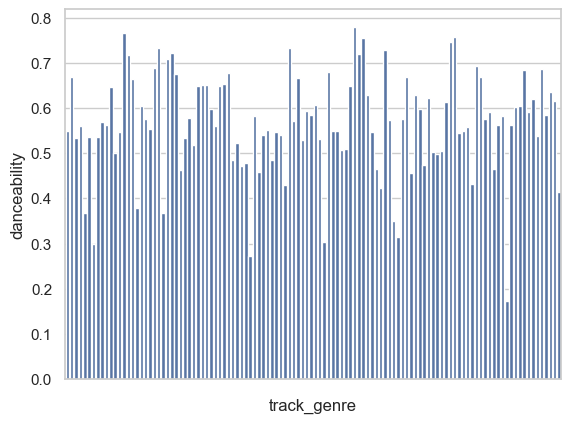

In [199]:
pop_results = df_rounded.groupby("track_genre")["danceability"].mean()
ax = sns.barplot(pop_results)
ax.set(xticklabels=[], )